In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import joblib 

def load_dataset():
    
    dataset_path = "./processed_datasets/final_dataset_org.csv"
    df = pd.read_csv(dataset_path)
    X = df.drop(columns=[ 'target'])
    y = df['target']
    
    return X, y

def load_cation_dataset():
    dataset_path = "./processed_datasets/final_dataset_cations_org.csv"
    df = pd.read_csv(dataset_path)
    X = df.drop(columns=[ 'target'])
    y = df['target']
    
    return X, y

def load_anion_dataset():
    dataset_path = "./processed_datasets/final_dataset_anions_org.csv"
    df = pd.read_csv(dataset_path)
    X = df.drop(columns=[ 'target'])
    y = df['target']
    
    return X, y

def run_baseline_regression(X, y, verbose=True):

    models = {
        'Ridge Regression': Ridge(),
        'Lasso Regression': Lasso(),
        'Elastic Net': ElasticNet(),
        'Decision Tree': DecisionTreeRegressor(),
        'Random Forest': RandomForestRegressor(),
        'Gradient Boosting': GradientBoostingRegressor(),
        'XGBoost': XGBRegressor(),
        'LightGBM': LGBMRegressor(verbosity=-1)
    }
    results = {}

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model_instance in tqdm(models.items(), desc="Cross-validating models", total=len(models)):
        # set n_jobs to -1 for parallel processing if available
        if hasattr(model_instance, 'n_jobs'):
            model_instance.n_jobs = -1
        elif hasattr(model_instance, 'nthread'):
            model_instance.nthread = -1

        scores = cross_val_score(model_instance, X, y, cv=cv, n_jobs=-1, scoring='r2')
        
        if verbose:
            print(f"{model_name} CV R2 scores: {scores.mean() :.4f}")

        results[model_name] = scores.mean()

    return results


In [25]:
X_total, y_total = load_dataset()
X_cation, _ = load_cation_dataset()
X_anion, _ = load_anion_dataset()

# Drop rows with missing values in X and y before splitting
X_clean = X_total.dropna()
y_clean = y_total[X_clean.index]

In [26]:
X_total.shape

(1217, 326)

Dataset shape: (1217, 326)
Starting training...


Cross-validating models:   0%|          | 0/8 [00:00<?, ?it/s]

Ridge Regression CV R2 scores: 0.7528
Lasso Regression CV R2 scores: 0.3856
Elastic Net CV R2 scores: 0.4617
Decision Tree CV R2 scores: 0.7221
Random Forest CV R2 scores: 0.8069
Gradient Boosting CV R2 scores: 0.8096
XGBoost CV R2 scores: 0.7953
LightGBM CV R2 scores: 0.8148


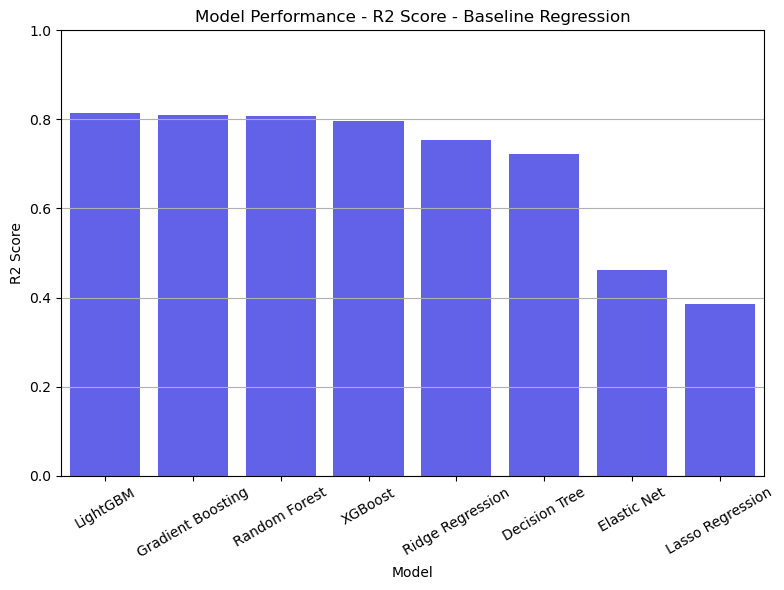

In [19]:
def train_baseline(X, y, k):
    X_clean = X.dropna()
    y_clean = y[X_clean.index]

    # Ensure all column names are strings
    X_clean.columns = X_clean.columns.astype(str)

    print("Dataset shape:",X_clean.shape)
    # Cross-validation or train/test
    print("Starting training...")
    # # Train and evaluate
    results = run_baseline_regression(X_clean, y_clean)

    return results

# plot results
results = train_baseline(X_clean, y_clean, k=10)

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'R2'])
results_df.sort_values(by='R2', ascending=False, inplace=True)
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='R2', data=results_df, color='blue', alpha=0.7)
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.ylim(0, 1)
plt.title('Model Performance - R2 Score - Baseline Regression')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.tight_layout()
plt.show()

In [27]:
def prep_data(X, y):
    X_clean = X.dropna()
    y_clean = y[X_clean.index]

    # Ensure all column names are strings
    X_clean.columns = X_clean.columns.astype(str)

    return X_clean, y_clean

def train_model_cv(X, y, model, return_model=False):
    X_prep, y_prep = prep_data(X, y)
    
    print("Dataset shape:",X_prep.shape)
    print("Starting training...")

    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_prep, y_prep, cv=cv, n_jobs=-1, scoring='r2')
    
    if return_model:
        model.fit(X_prep, y_prep)
        return scores.mean(), model
    
    return scores.mean()

def train_model(X, y, model):
    X_prep, y_prep = prep_data(X, y)

    print("Dataset shape:",X.shape)
    print("Starting training...")

    # Train and evaluate
    X_train, X_test, y_train, y_test = train_test_split(X_prep, y_prep, test_size=0.2, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return y_pred, y_test, model



In [ ]:
import optuna

X_prep, y_prep = prep_data(X_clean, y_clean)

def lgbm_objective(trial):

    lgbm_params = {
            'lambda': trial.suggest_float('lgbm_reg_lambda', 1e-8, 20.0, log=True),
            'alpha': trial.suggest_float('lgbm_reg_alpha', 1e-8, 20.0, log=True),
            'learning_rate': trial.suggest_float('lgbm_learning_rate', 0.005, 0.2, log=True),
            'n_estimators': trial.suggest_int('lgbm_n_estimators', 100, 1200),
            'min_child_weight': trial.suggest_int('lgbm_min_child_weight', 1, 20),
            'max_depth': trial.suggest_int('lgbm_max_depth', 3, 10),
            'subsample': trial.suggest_float('lgbm_subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('lgbm_colsample_bytree', 0.5, 1.0),
            'random_state': 42,
        }

    model = LGBMRegressor(**lgbm_params)
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_prep, y_prep, cv=cv, n_jobs=-1, scoring='r2')
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='lgbm_transformed', storage="sqlite:///optuna.db", load_if_exists=True)
study.optimize(lgbm_objective, n_trials=25, n_jobs=-1)

print("Best hyperparameters: ", study.best_params)
print("Best r2: ", study.best_value)

optim_model = LGBMRegressor(**study.best_params)
y_pred, y_test, trained_model = train_model(X_total, y_total, model=optim_model)

joblib.dump(optim_model, './models/optimized_gbm_model.pkl')

[I 2025-09-19 19:25:58,648] Using an existing study with name 'lgbm_transformed' instead of creating a new one.
[I 2025-09-19 19:27:45,435] Trial 37 finished with value: 0.8138728721972779 and parameters: {'lgbm_reg_lambda': 1.4993020937109683e-05, 'lgbm_reg_alpha': 5.450955655983441e-06, 'lgbm_learning_rate': 0.010114289769657149, 'lgbm_n_estimators': 905, 'lgbm_min_child_weight': 9, 'lgbm_max_depth': 10, 'lgbm_subsample': 0.5483008164255105, 'lgbm_colsample_bytree': 0.7146082290815716, 'lgbm_verbosity': -1}. Best is trial 10 with value: 0.8161782487879069.
[I 2025-09-19 19:27:47,520] Trial 36 finished with value: 0.8134883272922424 and parameters: {'lgbm_reg_lambda': 1.2584980439137776e-05, 'lgbm_reg_alpha': 5.561746986473143e-06, 'lgbm_learning_rate': 0.011025738889937221, 'lgbm_n_estimators': 923, 'lgbm_min_child_weight': 20, 'lgbm_max_depth': 10, 'lgbm_subsample': 0.5719618863944356, 'lgbm_colsample_bytree': 0.7122252108440371, 'lgbm_verbosity': -1}. Best is trial 10 with value: 0

Best hyperparameters:  {'lgbm_reg_lambda': 1.4490766745821302, 'lgbm_reg_alpha': 4.642462832715582e-05, 'lgbm_learning_rate': 0.007677819180079963, 'lgbm_n_estimators': 1007, 'lgbm_min_child_weight': 5, 'lgbm_max_depth': 9, 'lgbm_subsample': 0.5002431527670587, 'lgbm_colsample_bytree': 0.5605167683130016, 'lgbm_verbosity': -1}
Best r2:  0.8175490114728614
Dataset shape: (1217, 326)
Starting training...
[LightGBM] [Warning] Unknown parameter: lgbm_reg_alpha
[LightGBM] [Warning] Unknown parameter: lgbm_reg_lambda
[LightGBM] [Warning] Unknown parameter: lgbm_learning_rate
[LightGBM] [Warning] Unknown parameter: lgbm_n_estimators
[LightGBM] [Warning] Unknown parameter: lgbm_subsample
[LightGBM] [Warning] Unknown parameter: lgbm_colsample_bytree
[LightGBM] [Warning] Unknown parameter: lgbm_min_child_weight
[LightGBM] [Warning] Unknown parameter: lgbm_verbosity
[LightGBM] [Warning] Unknown parameter: lgbm_max_depth
[LightGBM] [Warning] Unknown parameter: lgbm_reg_alpha
[LightGBM] [Warning] U

['./models/optimized_gbm_model.pkl']

In [40]:
# training a voting regressor with the best model
import optuna
from sklearn.ensemble import VotingRegressor

def optimize_voting_regressor(X, y, n_trials=100):
    
    X_prep, y_prep = prep_data(X, y)

    def xgb_objective(trial):
        xgb_params = {
            'reg_lambda': trial.suggest_float('xgb_lambda', 1e-8, 20.0, log=True),
            'reg_alpha': trial.suggest_float('xgb_alpha', 1e-8, 20.0, log=True),
            'gamma': trial.suggest_float('xgb_gamma', 0, 10),
            'learning_rate': trial.suggest_float('xgb_learning_rate', 0.005, 0.2, log=True),
            'n_estimators': trial.suggest_int('xgb_n_estimators', 100, 1200),
            'random_state': 42,
        }

        xgb = XGBRegressor(**xgb_params)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(xgb, X_prep, y_prep, cv=cv, n_jobs=-1, scoring='r2')
        return scores.mean()
    
    xgb_study = optuna.create_study(direction='maximize', study_name='xgb_study')
    xgb_study.optimize(xgb_objective, n_trials=n_trials)
    xgb_params = xgb_study.best_params

    def gbm_objective(trial):
        gbm_params = {
            'learning_rate': trial.suggest_float('gbm_learning_rate', 0.005, 0.2, log=True),
            'n_estimators': trial.suggest_int('gbm_n_estimators', 100, 1200),
            'max_depth': trial.suggest_int('gbm_max_depth', 3, 10),
            'random_state': 42, #constant
        }

        gbm = GradientBoostingRegressor(**gbm_params)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(gbm, X_prep, y_prep, cv=cv, n_jobs=-1, scoring='r2')
        return scores.mean()

    gbm_study = optuna.create_study(direction='maximize', study_name='gbm_study')
    gbm_study.optimize(gbm_objective, n_trials=n_trials)
    gbm_params = gbm_study.best_params

    def rf_objective(trial):
        rf_params = {
            'n_estimators': trial.suggest_int('rf_n_estimators', 100, 1200),
            'max_depth': trial.suggest_int('rf_max_depth', 3, 10),
            'min_samples_split': trial.suggest_int('rf_min_samples_split', 2, 20),
            'random_state': 42,  # constant
        }

        rf = RandomForestRegressor(**rf_params)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(rf, X_prep, y_prep, cv=cv, n_jobs=-1, scoring='r2')
        return scores.mean()

    rf_study = optuna.create_study(direction='maximize', study_name='rf_study')
    rf_study.optimize(rf_objective, n_trials=n_trials)
    rf_params = rf_study.best_params

    def lgbm_objective(trial):
        lgbm_params = {
            'lambda': trial.suggest_float('lgbm_reg_lambda', 1e-8, 20.0, log=True),
            'alpha': trial.suggest_float('lgbm_reg_alpha', 1e-8, 20.0, log=True),
            'learning_rate': trial.suggest_float('lgbm_learning_rate', 0.005, 0.2, log=True),
            'n_estimators': trial.suggest_int('lgbm_n_estimators', 100, 1200),
            'random_state': 42,
            'verbosity': -1,  # Suppress warnings
        }

        lgbm = LGBMRegressor(**lgbm_params)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(lgbm, X_prep, y_prep, cv=cv, n_jobs=-1, scoring='r2')
        return scores.mean()

    lgbm_study = optuna.create_study(direction='maximize', study_name='lgbm_study')
    lgbm_study.optimize(lgbm_objective, n_trials=n_trials)
    lgbm_params = lgbm_study.best_params

    # Extract params for each model by filtering & stripping prefixes
    xgb_final_params = {k.replace("xgb_", ""): v for k, v in xgb_params.items() if k.startswith("xgb_")}
    gbm_final_params = {k.replace("gbm_", ""): v for k, v in gbm_params.items() if k.startswith("gbm_")}
    lgbm_final_params = {k.replace("lgbm_", ""): v for k, v in lgbm_params.items() if k.startswith("lgbm_")}
    rf_final_params = {k.replace("rf_", ""): v for k, v in rf_params.items() if k.startswith("rf_")}

    voting_reg = VotingRegressor(
        estimators=[
            ('xgb', XGBRegressor(**xgb_final_params)),
            ('gbm', GradientBoostingRegressor(**gbm_final_params)),
            ('rf', RandomForestRegressor(**rf_final_params)),
            ('lgbm', LGBMRegressor(verbosity=-1, **lgbm_final_params))
        ],
        n_jobs=-1,
        verbose=False
    )

    score = cross_val_score(voting_reg, X_prep, y_prep, cv=5, scoring='r2').mean()
    return score, voting_reg

voting_score, voting_model = optimize_voting_regressor(X_clean, y_clean, n_trials=25)
final_score, voting_model_tuned = train_model_cv(X_clean, y_clean, model=voting_model, return_model=True)
print(f"Final Voting Regressor R2 score: {final_score :.4f}")
joblib.dump(voting_model_tuned, './models/voting_model.pkl')

print(f"Voting Regressor CV R2 scores: {final_score :.4f}")

[I 2025-09-20 19:33:02,303] A new study created in memory with name: xgb_study
[I 2025-09-20 19:33:07,484] Trial 0 finished with value: 0.8021285085940081 and parameters: {'xgb_lambda': 0.7247347497119041, 'xgb_alpha': 0.008204951344320994, 'xgb_gamma': 2.7578802737485453, 'xgb_learning_rate': 0.08758339594340515, 'xgb_n_estimators': 369}. Best is trial 0 with value: 0.8021285085940081.
[I 2025-09-20 19:33:10,580] Trial 1 finished with value: 0.8011463289793523 and parameters: {'xgb_lambda': 0.0001699311131603616, 'xgb_alpha': 0.2372912060150932, 'xgb_gamma': 3.76250176668659, 'xgb_learning_rate': 0.07752507935417564, 'xgb_n_estimators': 663}. Best is trial 0 with value: 0.8021285085940081.
[I 2025-09-20 19:33:15,440] Trial 2 finished with value: 0.8082052402561425 and parameters: {'xgb_lambda': 1.9425083981422229, 'xgb_alpha': 1.015661718069452e-06, 'xgb_gamma': 1.2397465186160639, 'xgb_learning_rate': 0.03802748210388349, 'xgb_n_estimators': 204}. Best is trial 2 with value: 0.808205

Dataset shape: (1217, 326)
Starting training...
Final Voting Regressor R2 score: 0.8127
Voting Regressor CV R2 scores: 0.8127


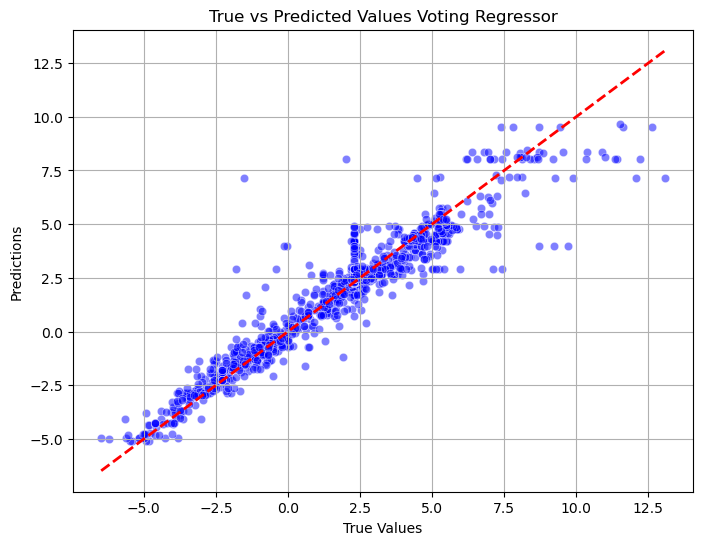

In [41]:
y_pred = voting_model_tuned.predict(X_clean)

import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_clean, y=y_pred, color='blue', alpha=0.5)
plt.plot([y_clean.min(), y_clean.max()], [y_clean.min(), y_clean.max()], color='red', linestyle='--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.grid()
plt.title('True vs Predicted Values Voting Regressor')
plt.savefig('figures/voting_reg_output.jpg', dpi=300)
plt.show()


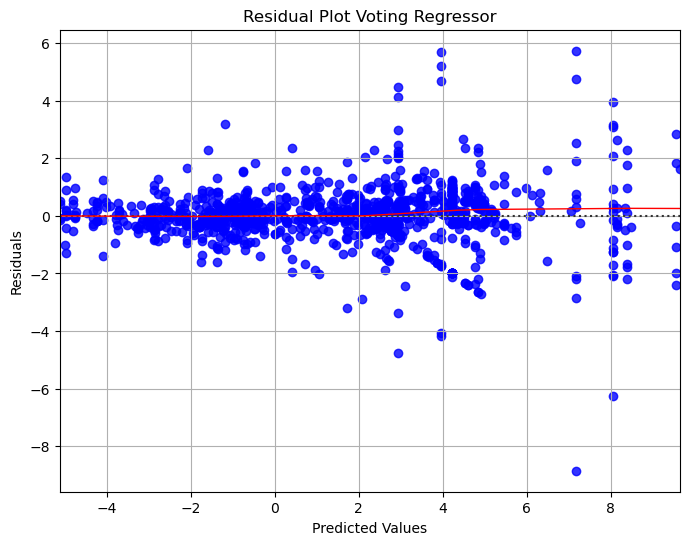

In [42]:
# residual plot

plt.figure(figsize=(8, 6))
sns.residplot(x=y_pred, y=y_clean - y_pred, lowess=True, color='blue', line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot Voting Regressor')
plt.grid()
plt.savefig('figures/voting_reg_residuals.jpg', dpi=300)
plt.show()